# **Title: Software Development 2: Assignment 2**

**Date: 20.04.2026**

## **Group: Osahon Joseph Osazuwa // Santhosh Sandramol // Thomas Wolfgang Maurer**

**Question 1 - Student Data Rescue: CSV, Excel, and Cleaning**

Build and rescue a messy student-performance dataset by combining file loading, inspection, and cleaning operations from class.

Tasks

a) Create a CSV file named raw_students.csv with at least 16 rows and the columns Student_ID, Name, Group, Subject, Attendance, Quiz, Assignment, and Exam.

b) Create a second Excel file named student_bonus.xlsx with the columns Student_ID and Bonus. Load both files using read_csv() and read_excel().

c) Intentionally include at least 2 missing values, 2 duplicate rows, 2 inconsistent text values, 2 wrong data types, and 1 suspicious numeric value in the raw CSV file.

d) Inspect the raw data using head(), tail(), info(), describe(), and isnull().sum().

e) Clean the dataset using a reasonable combination of replace(), fillna(), drop_duplicates(), and astype().

f) Merge the bonus file into the cleaned student dataset using Student_ID as the matching key. Then create Final_Score using your own clear rule and create Passed using a pass condition that you define explicitly.

g) Print the cleaned dataset and clearly show that the major data problems were fixed.

h) Save the final cleaned result as clean_students.xlsx.

Required written reflection
- Why is it risky to begin analysis before checking the raw data carefully?
- Why did you choose to fix some values instead of dropping all problematic rows?
- Why was dtype conversion important in your solution?

In [78]:
import pandas as pd
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/raw_students.csv')
df2 = pd.read_excel('/content/drive/MyDrive/student_bonus.xlsx')


#(a) csv file created as instructed...

#(b) xlsx file also created as instructed...

#(c) Instructed parameters added to the csv file as instructed

#(d) Data inspection

print("Raw csv:\n")
print(df)


print("head():\n")
print(df.head())  #prints the first 5 rows

print("\ntail():\n")
print(df.tail())   #prints the last 5 rows

print("\ninfo():\n")
print(df.info())    #prints columns, non-null count, and Dtype

print("\ndescribe():\n")
print(df.describe())   #prints mean,std,max,min and whatnot

#(e) Cleaning the dataset...

df = df.drop_duplicates() #removed any duplicate rows


#used the replace method in several column
df['Group'] = df['Group'].replace("group a","Group A")

df['Group'] = df['Group'].replace("GROUP C","Group C")

df['Quiz'] = df['Quiz'].replace("A+","19")

df['Exam'] = df['Exam'].replace("seventy","70")

df["Exam"] = df["Exam"].astype(int) #changed the Dtype of the Exam column

df['Exam'] = df['Exam'].replace(999,df['Exam'].median()) # replaced the suspicious numeric value of 999 with the median of the column (Not sure what the protocol should have been here)

#filling missing values
df['Attendance'] = df['Attendance'].fillna(0)

#changing Dtypes
df['Quiz'] = df['Quiz'].astype(int)
df['Assignment'] = df['Assignment'].astype(int)
df['Attendance'] = df['Attendance'].astype(int)

df = df.reset_index(drop=True) #resetting the index

print("Cleaned csv:\n")
print(df)

#(f) Merging the csv and xlsx files

merged_file = df.merge(df2, on='Student_ID')

print("Merged_file:\n")
print(merged_file)

# creating Final_score column
merged_file['Final_Score'] = (merged_file['Quiz'] + merged_file['Assignment'] + merged_file['Exam'] + merged_file['Bonus'])

#created passed column
merged_file['Passed'] = merged_file['Final_Score'] >= 170

#(g) Printing the final file
print("Final_file:\n")
print(merged_file)

#(h)Saving the file
merged_file.to_excel('clean_students.xlsx', index=False)





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw csv:

    Student_ID            Name    Group  Subject  Attendance Quiz  Assignment  \
0         1001   Alice Johnson  Group A     Math        92.0   18          85   
1         1002       Bob Smith  group a  Science        88.0   15          90   
2         1003     Carol White  Group B     Math        76.0   12          70   
3         1004       David Lee  Group B  English        95.0   19          95   
4         1005    Eva Martinez  Group A  Science         NaN   14          80   
5         1006     Frank Brown  Group C     Math        83.0   16          75   
6         1007       Grace Kim  GROUP C  English        90.0   17          88   
7         1008    Henry Wilson  Group A  Science        78.0   13          72   
8         1009     Isla Thomas  Group B     Math        85.0   A+          91   
9         1010      Jack Davis  Group C  English   

**Reflection**

1. Why is it risky to begin analysis before checking the raw data carefully?

It's risky because datasets are rarely ever perfect from the get-go, there could be duplicates, missing values, wrong data types and whatnot. Working with them in their raw state would most likely lead to false results. Hence, cleaning the data first before working with it is extremely important.

2. Why did you choose to fix some values instead of dropping all problematic rows?

Because dropping everything wastes data. Fixing preserves information and avoids unnecessary loss.

3. Why was dtype conversion important in your solution?

 Because correct data types unlock correct operations. Without them, Pandas behaves unpredictably and can raise errors if you attempt to use the wrong operation on an imcompatible data type.

**Question 2 - Filtering, Selection, and Ranking Challenge**

Use the cleaned student dataset to answer more targeted questions through selection, filtering, sorting, and ranking.

Tasks

a) Load clean_students.xlsx into a DataFrame.

b) Select one single column as a Series and at least two columns as a DataFrame. Print both and comment on the difference in structure.

c) Use loc to extract one specific row, one slice of rows, and all rows where Final_Score is above a threshold of your choice.

d) Use iloc to extract the first row, rows 2 to 5, and two non-consecutive rows of your choice.

e) Use query() to create at least two meaningful filtered subsets, for example low attendance but high exam score, or strong quiz performance but weak assignment performance.

f) Sort the dataset at least twice using sort_values(), once by Final_Score and once by Attendance.

g) Create a ranking table with the top 5 students and save it as ranking_report.csv.

Required written reflection
- What is the practical difference between selecting one column and several columns in Pandas?
- When is query() clearer than a long bracket-based filter?
- In your own words, what is the difference between loc and iloc?

In [79]:
#(a) Loading the dataset

df = pd.read_excel('/content/drive/MyDrive/clean_students.xlsx')
print(df)

#(b) Selecting column(s)

# Selecting one column as a series
df_series = df['Name']
print("#A series is one-dimensional (one single column). Attaches values to an index as displayed below... \n")
print(df_series)

#Selecting multiple columns as a dataframe
df_dataframe = df[["Name","Subject","Quiz"]]
print("\n#A dataframe is two-dimensional (rows and columns). Collection of multiple series... \n")
print(df_dataframe)

#(c) loc
# loc to extract one specific row
df.loc[4]

# loc to extract a slice of rows
df.loc[4:10]

# loc to extract all rows where Final_Score is above a threshold
df.loc[df['Final_Score'] > 170, 'Final_Score']

#(d) iloc
# iloc to extract the first row
df.iloc[0]

# iloc to extract rows 2 to 5
df.iloc[2:6]

# iloc to extract two non-consecutive rows
df.iloc[[5,11]]

#(e) Using Query
df.query('Assignment > 70')

df.query('Attendance < 80'and 'Final_Score > 170')

#(f) Using the sort method


df.sort_values('Final_Score', ascending=False)

df.sort_values(by='Attendance', ascending=False)

#(g) Creating a ranking table
best_students = df.sort_values(by='Final_Score', ascending=False).head(5) #top 5 best students

best_students.to_csv('ranking_report.csv', index=False)


    Student_ID            Name    Group  Subject  Attendance  Quiz  \
0         1001   Alice Johnson  Group A     Math          92    18   
1         1002       Bob Smith  Group A  Science          88    15   
2         1003     Carol White  Group B     Math          76    12   
3         1004       David Lee  Group B  English          95    19   
4         1005    Eva Martinez  Group A  Science           0    14   
5         1006     Frank Brown  Group C     Math          83    16   
6         1007       Grace Kim  Group C  English          90    17   
7         1008    Henry Wilson  Group A  Science          78    13   
8         1009     Isla Thomas  Group B     Math          85    19   
9         1010      Jack Davis  Group C  English           0    11   
10        1011    Karen Garcia  Group A     Math          91    18   
11        1012  Liam Rodriguez  Group B  Science          69    10   
12        1013   Mia Hernandez  Group C  English          97    20   
13        1014      

**Reflection**
1. What is the practical difference between selecting one column and several columns in Pandas?

*   When you grab one column, Pandas hands you a Series.
*   When you grab multiple columns, Pandas gives you a DataFrame or an excel sheet.

2. When is query() clearer than a long bracket-based filter?

Bracket filters are fine, but it looks more complicated to read. Query method reads more like English and is better for multiple conditions.

3. In your own words, what is the difference between loc and iloc?


*   loc = “give me the row/column with this NAME.”
*   loc = “give me the row/column with this INDEX/POSITION.”



**Question 3 - GroupBy and Pivot Table Performance Audit**

Summarize the cleaned data from multiple angles using grouped statistics and pivot tables.

Tasks

a) Group the data by Subject and calculate mean, sum, count, max, and min for Final_Score.

b) Group the data by Group and calculate at least three aggregate statistics for Exam.

c) Create a pivot table where rows = Group, columns = Subject, and values = Final_Score using mean as the aggregation function.

d) Create a second pivot table of your choice that answers a different question, such as average Attendance or count of students.

e) Identify the strongest group, the weakest subject, and one interesting imbalance in the dataset.

f) Save the grouped summary and the pivot tables in a clearly organized file named performance_summary.xlsx.

Required written reflection
- Why is groupby() useful when a dataset becomes larger?
- How is a pivot table different from a normal grouped summary?
- Which statistic or table revealed the most useful insight in your analysis, and why?

In [80]:
df = pd.read_excel('/content/drive/MyDrive/clean_students.xlsx')

#(a) Groupby
group1 = df.groupby('Subject')['Final_Score'].agg(['mean', 'sum', 'count', 'max', 'min'])

#(b) Groupby
group2 = df.groupby('Group')['Exam'].agg(['mean', 'sum', 'count'])

#(c) Pivot table
pivot_table1 = df.pivot_table(index='Group', columns='Subject', values='Final_Score', aggfunc='mean')

#(d) Pivot table of my choosing...
pivot_table2 = df.pivot_table(index='Group', columns='Passed', values='Attendance', aggfunc='sum')

#(e) Seeking out the strongest group...
print("Based on these results, Group A seems to have the average highest final score and also has the highest passed count...\n")

print(group1)

print("\n")

print(df.groupby('Group')['Passed'].count())

print("\n")

#The weakest subject....
print("Based on the below results, science had the average lowest final score. Students seemed to have performed the least on this subject...\n ")
print(df.groupby('Subject')['Final_Score'].mean())

print("\n")

#An intesresting imbalance as observed...
print("As observed below, suprisingly and somewhat laughable, nobody in Group A took an English exam. I wonder why...\n")
print(pivot_table1)

#(f) Saving the groups and pivot tables
import pandas as pd

# Dictionary of all tables you want to save
tables = {
    "Group 1": group1,
    "Group 2": group2,
    "Pivot 1": pivot_table1,
    "Pivot 2": pivot_table2
}

with pd.ExcelWriter("performance_summary.xlsx", engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        df.to_excel(writer, sheet_name=sheet_name, index=True)




Based on these results, Group A seems to have the average highest final score and also has the highest passed count...

          mean   sum  count  max  min
Subject                              
English  185.6   928      5  213  139
Math     174.5  1047      6  193  147
Science  155.8   779      5  190  127


Group
Group A    6
Group B    5
Group C    5
Name: Passed, dtype: int64


Based on the below results, science had the average lowest final score. Students seemed to have performed the least on this subject...
 
Subject
English    185.6
Math       174.5
Science    155.8
Name: Final_Score, dtype: float64


As observed below, suprisingly and somewhat laughable, nobody in Group A took an English exam. I wonder why...

Subject     English   Math  Science
Group                              
Group A         NaN  181.0    172.0
Group B  196.000000  170.0    127.0
Group C  178.666667  164.0    136.0


**Reflection**
1. Why is groupby() useful when a dataset becomes larger?

When a dataset is kind of large, it becomes harder to understand anything by looking at individual rows. So groupby() helps by breaking the data into meaningful categories and summarizing each one. Instead of dealing with thousands of entries, you suddenly have a small and organized table that highlights patterns, differences, and trends. It's very useful when it comes to data interpretation.

2. How is a pivot table different from a normal grouped summary?

A grouped summary looks at one dimension at a time (average final_score per subject like an example above).
A pivot table compares two dimensions at once, it reveals relationships and trends that a simple groupby can’t show.

3. Which statistic or table revealed the most useful insight in your analysis, and why?

The pivot table method offered the strongest insight to be honest. I didn't even know such a method existed in pandas prior to this assignment. I've mostly ever used groupy(). It showed how categories behaved across another variable. You can choose the row, the column, the values and then the aggregate function. Very useful indeed.

**Question 4 - Visualization Dashboard and Insight Report**

Create a small analysis dashboard that turns your tables into visible patterns and interpretations.

Tasks

a) Using the cleaned dataset, create a seaborn barplot showing the average Final_Score by Subject.

b) Create a seaborn boxplot showing the Final_Score distribution by Group.

c) Create a seaborn scatterplot showing the relationship between Attendance and Final_Score, and use one categorical variable as hue.

d) Create a heatmap based on a table that you build from your grouped or pivoted results.

e) Create one pandas line plot and one histogram using meaningful columns from the dataset.

f) All plots must include proper titles, axis labels, and readable layout.

g) Write a short insight report with at least 5 clear observations based on your figures.

Required written reflection
- Which visualization was most useful for finding outliers, and why?
- Which visualization was best for comparing categories?
- Why are visualizations often more helpful than raw tables when explaining results to others?

    Student_ID            Name    Group  Subject  Attendance  Quiz  \
0         1001   Alice Johnson  Group A     Math          92    18   
1         1002       Bob Smith  Group A  Science          88    15   
2         1003     Carol White  Group B     Math          76    12   
3         1004       David Lee  Group B  English          95    19   
4         1005    Eva Martinez  Group A  Science           0    14   
5         1006     Frank Brown  Group C     Math          83    16   
6         1007       Grace Kim  Group C  English          90    17   
7         1008    Henry Wilson  Group A  Science          78    13   
8         1009     Isla Thomas  Group B     Math          85    19   
9         1010      Jack Davis  Group C  English           0    11   
10        1011    Karen Garcia  Group A     Math          91    18   
11        1012  Liam Rodriguez  Group B  Science          69    10   
12        1013   Mia Hernandez  Group C  English          97    20   
13        1014      

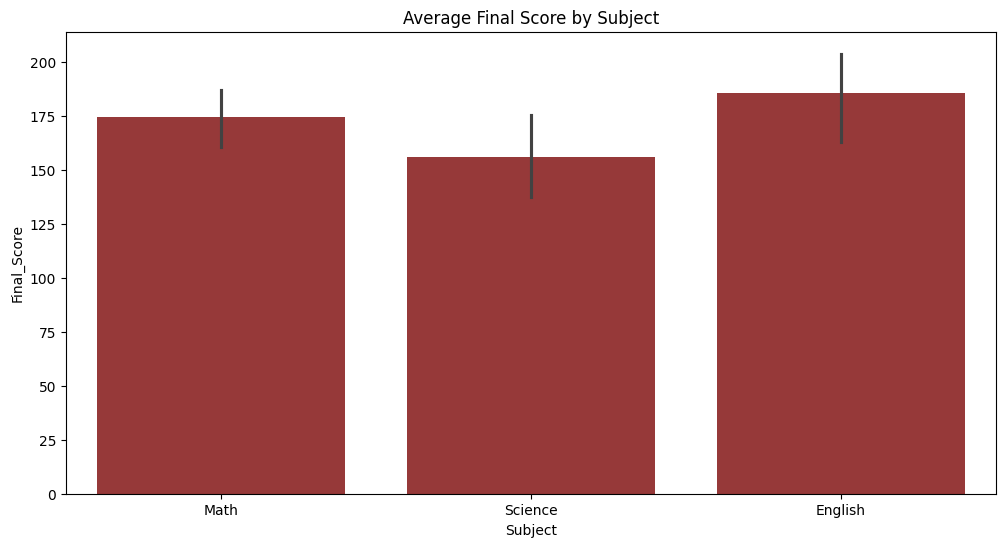

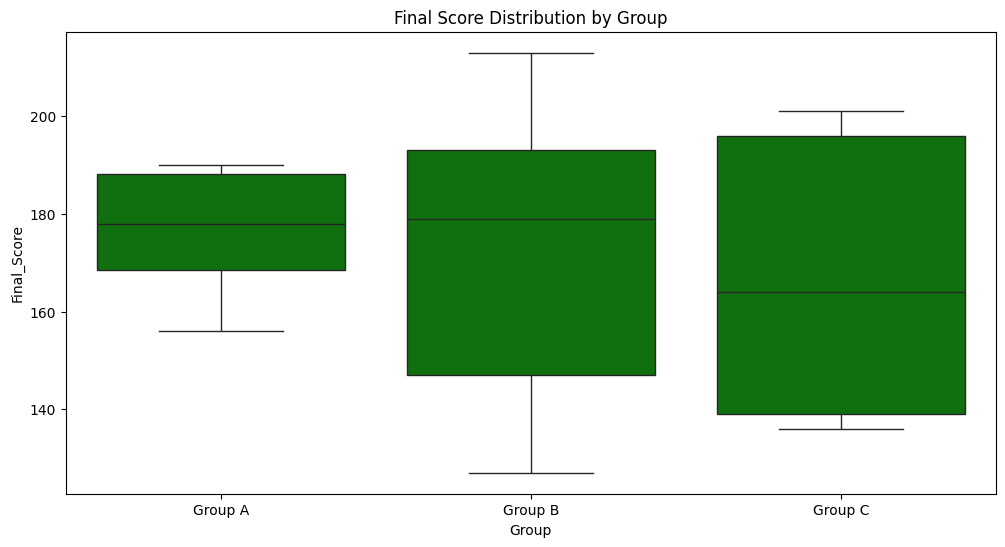

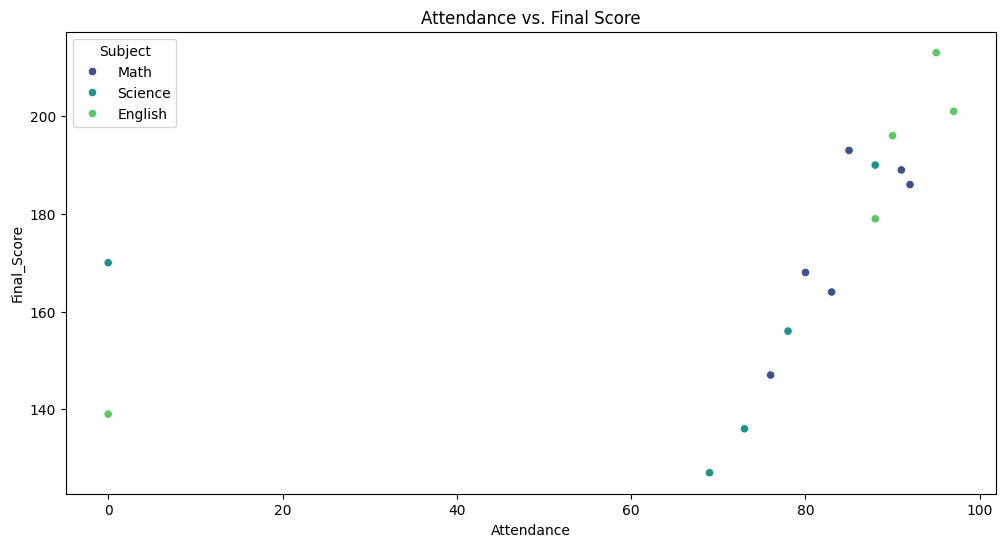

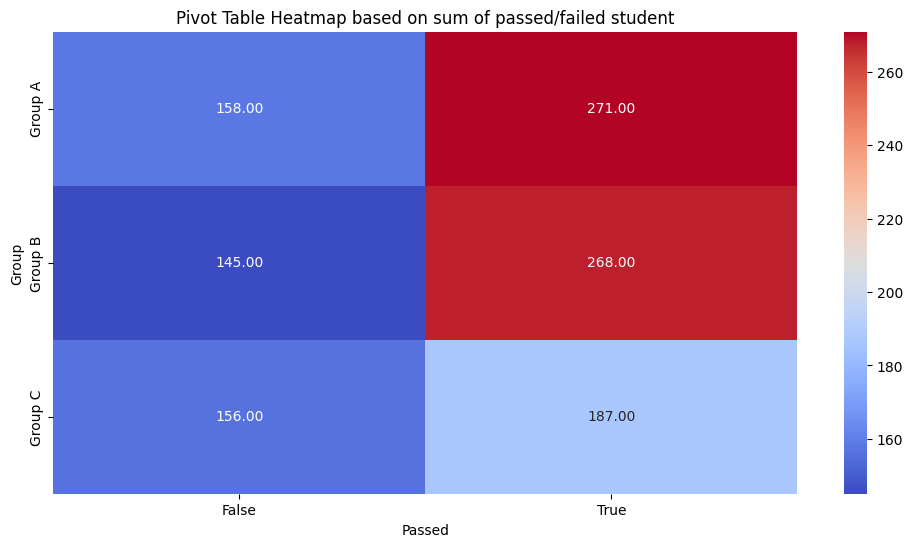

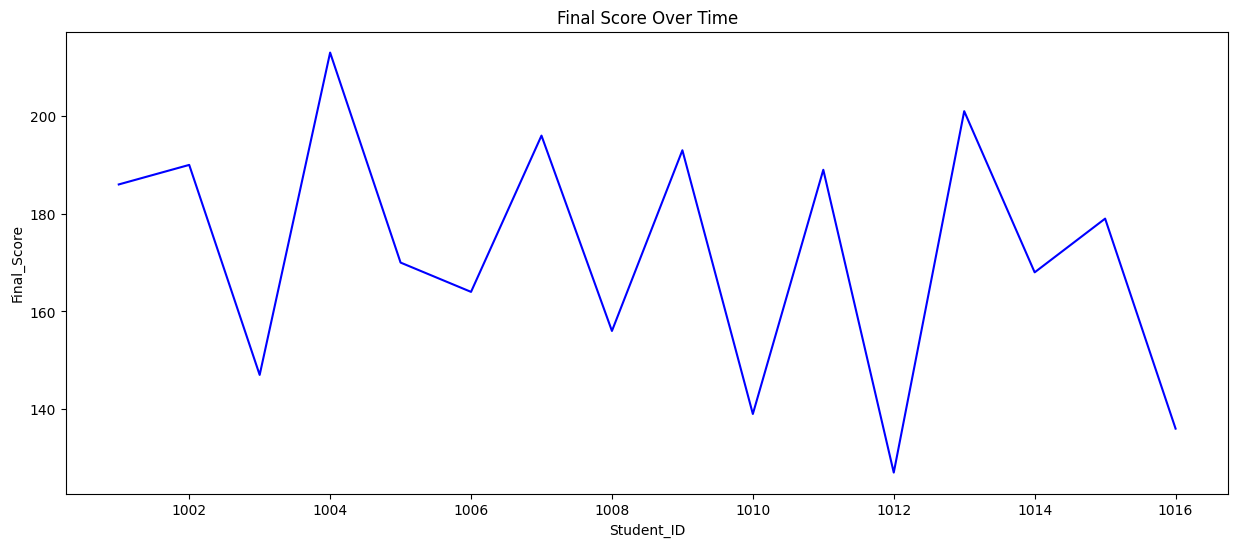

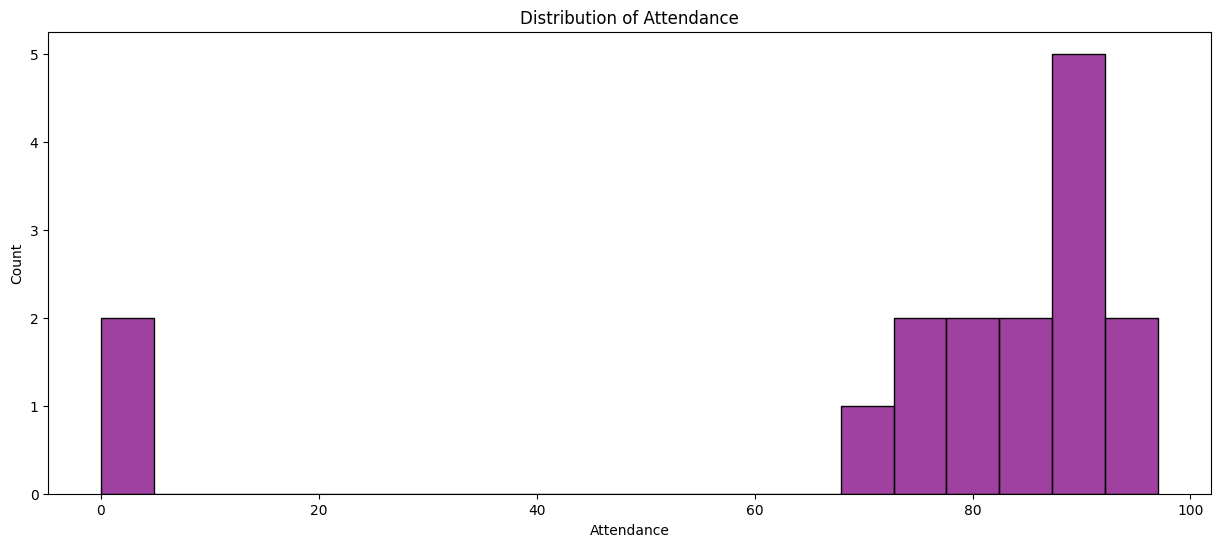

In [98]:
from numpy import average
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('/content/drive/MyDrive/clean_students.xlsx')

print(df)

#(a) seaborn barplot showing the average Final_Score by subject
plt.figure(figsize=(12, 6))
sns.barplot(x='Subject', y='Final_Score', data=df, color="brown")
plt.title('Average Final Score by Subject')
plt.show()

print("\n")

#(b) seaborn boxplot showing the Final_Score distribution by Group
plt.figure(figsize=(12, 6))
sns.boxplot(x='Group', y='Final_Score', data=df, color="green")
plt.title('Final Score Distribution by Group')
plt.show()

print("\n")

#(c) seaborn scatterplot showing the relationship between Attendance and Final_Score, and use one categorical variable as hue
plt.figure(figsize=(12, 6))
sns.scatterplot(x='Attendance', y='Final_Score', data=df, hue='Subject', palette='viridis')
plt.title('Attendance vs. Final Score')
plt.show()

print("\n")

#(d) heatmap based on a table that you build from your grouped or pivoted results
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table2, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pivot Table Heatmap based on sum of passed/failed student')
plt.show()

print("\n")

#(e) pandas line plot and one histogram using meaningful columns from the dataset
plt.figure(figsize=(15, 6))
sns.lineplot(x='Student_ID', y='Final_Score', data=df, color='blue')
plt.title('Final Score Over Time')
plt.show()

print("\n")

plt.figure(figsize=(15, 6))
sns.histplot(df['Attendance'], bins=20, color='purple')
plt.title('Distribution of Attendance')
plt.show()

#(f) All parameters included as instructed...




(f)

**Reflection**
1. Which visualization was most useful for finding outliers, and why?

The boxplot was the most useful for spotting outliers because it highlights unusual values immediately. Anything that falls outside the whiskers thingy stands out visually, so you don’t have to scan through numbers to notice who performed far above or below the typical range.

2. Which visualization was best for comparing categories?

The barplot was the best for comparing categories because it shows the average value for each group side by side. As observed aboved for the subject and final score, you can instantly tell which category performs highest, lowest, or sits in the middle.

3. Why are visualizations often more helpful than raw tables when explaining results to others?

Visualizations make patterns obvious in a way that tables rarely do. People understand shapes, colors, and trends much faster than rows of numbers. I certainly am a visual learner. A good chart can show relationships or problems in seconds, and it's muchh easier to communicate insights clearly especially to someone who isn’t deep into the data sphere and not too techy savvy.